# Nonparametric SFH fits to JWST broad and medium bands

> ⚠️ **Experimental.** A research demonstration using experimental APIs that may change between releases.

A Prospector-style setup: the `continuity` star-formation history
(piecewise-constant SFR in age bins, Student-t priors on the log ratios of
adjacent bins, following Leja et al. 2019) fit to JWST NIRCam photometry at
$z = 1.5$, first for one galaxy and then for a small catalog. The physics is
standard; the point of this page is operational. Two settings decide whether
the fit is worth anything: bin edges that follow the redshift, and a
trajectory long enough to cross a correlated ratio posterior.

The filter set is 7 broad bands (F090W to F444W) plus 12 medium bands (F140M
to F480M). At $z = 1.5$ the medium bands sample the rest-frame optical
continuum whose shape the ratio bins respond to, and F162M lands on
H$\alpha$, so the fit uses a wNE stellar library with nebular emission baked
into the templates.

In [1]:
import time
import warnings

# _setup must be imported before jax: it sets TF_CPP_MIN_LOG_LEVEL, which XLA
# only reads at import.
from _plot_style import setup_style
from _setup import FIG_DIR, effective_wavelengths_um, quiet

quiet()
setup_style()

# Correct notices, correct to ignore here: the wNE library warns that nebular
# emission is already in the templates and must be paired with the baked-in
# backend, which is the pairing used below; two_component reports the dust
# parameters it holds fixed, and holding them fixed is the point.
warnings.filterwarnings("ignore", message=r"(?s).*is a wNE .*")
warnings.filterwarnings("ignore", message=r"(?s).*run with that physics held constant.*")
# The dense-metric memory guard is written for NUTS and advises switching to
# mcmc_hmc, which is what runs here: it keys on the metric, not the sampler.
# Measured peak for this 9-parameter fit is a few GB, not the 20+ GB it warns of.
warnings.filterwarnings("ignore", message=r"(?s).*NUTS warmup with dense_mass_matrix.*")

import jax
import matplotlib.pyplot as plt
import numpy as np
from blackjax.diagnostics import effective_sample_size

import tengri
from tengri import (
    FIXED,
    FREE,
    Catalog,
    Fixed,
    ForwardModel,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
)
from tengri.cosmology import age_at_z

## Model

Nine free parameters: total mass plus six bin ratios from the SFH, stellar
metallicity, and the diffuse dust optical depth. `WavePrecomp` routes
photometry through a precomputed SSP-by-filter table, which is what makes the
samplers below affordable.

The bin edges are tied to the redshift, and that is not cosmetic. The
`continuity` default is a fixed ladder out to 13.7 Gyr whatever the redshift,
while the composite-population kernel drops star formation older than the
universe at the fit redshift. At $z = 1.5$ the two oldest bins then sit
outside cosmic time: they take no likelihood and sample their Student-t prior,
and the mass normalization counts them anyway. Measured on this model, a flat
history declared at $\log M = 10.3$ forms 9.80 on the default ladder, half a
dex short. Log-spacing the edges out to the age of the universe, as Prospector
does, returns 10.30. A `SFHBeforeBigBangWarning` still fires even so, because
the piecewise SFH holds its oldest bin's rate past the last edge (#1978), and
the shared notebook setup silences it. The normalization is not affected.

In [2]:
Z_GAL = 1.5
SNR = 20.0
N_WARMUP = 1000
N_SAMPLES = 400
N_LEAPFROG = 150

BROAD = [
    "jwst_f090w",
    "jwst_f115w",
    "jwst_f150w",
    "jwst_f200w",
    "jwst_f277w",
    "jwst_f356w",
    "jwst_f444w",
]
MEDIUM = [
    "jwst_f140m",
    "jwst_f162m",
    "jwst_f182m",
    "jwst_f210m",
    "jwst_f250m",
    "jwst_f300m",
    "jwst_f335m",
    "jwst_f360m",
    "jwst_f410m",
    "jwst_f430m",
    "jwst_f460m",
    "jwst_f480m",
]

ssp_data = tengri.load_ssp("prsc_miles_chabrier_wNE")
phot = Photometry.from_names(BROAD + MEDIUM)

# Two youngest edges fixed, the rest log-spaced to the age of the universe.
# Eight edges, so still seven bins and the six ratios the model declares.
T_UNIV = float(age_at_z(Z_GAL))
BIN_EDGES = np.concatenate([[0.0, 0.03], np.logspace(np.log10(0.1), np.log10(T_UNIV), 6)])
print(f"age of universe at z = {Z_GAL}: {T_UNIV:.2f} Gyr")
print("bin edges [Gyr]: " + ", ".join(f"{e:.2f}" for e in BIN_EDGES))

t0 = time.perf_counter()
model = SEDModel.build(
    ssp_data=ssp_data,
    observation=Observation(photometry=phot),
    redshift=Fixed(Z_GAL),
    sfh={"type": "continuity", "all_params": FREE, "bin_edges_gyr": BIN_EDGES},
    # 'all_params': FIXED states what the group already does by default. It is
    # here because the disposition is otherwise unstated, which warns: the two
    # remaining metallicity parameters are nuisance knobs this page does not
    # vary, and saying so is what keeps them out of the rendered output.
    met={"logzsol": Uniform(-1.5, 0.3), "all_params": FIXED},
    dust_attenuation={
        "type": "two_component",
        "law": "calzetti",
        "all_params": FIXED,
        # Diffuse screen only, stated rather than inherited. Leaving tau_bc out
        # gave it its declared default of 1.0 -- a frozen magnitude of extra
        # attenuation on every young population, which trades against recent SFR
        # and so is not a neutral nuisance pin in an SFH-recovery fit.
        "tau_bc": 0.0,
        "tau_diff": Uniform(0.0, 2.0),
    },
    neb={"type": "ssp"},
    approx=WavePrecomp(),
)
build_wall = time.perf_counter() - t0

MASS_KEY = next(k for k in model.spec.free_params if k.endswith("log_total_mass"))
RATIO_KEYS = [p for p in model.spec.free_params if "ratio" in p]
FIXED_VALUES = dict(model.spec.get_fixed_values())
print(f"build + WavePrecomp table: {build_wall:.1f} s")
print(f"free parameters ({model.spec.n_free}): {', '.join(model.spec.free_params)}")

age of universe at z = 1.5: 4.28 Gyr
bin edges [Gyr]: 0.00, 0.03, 0.10, 0.21, 0.45, 0.95, 2.02, 4.28


build + WavePrecomp table: 1.5 s
free parameters (9): dust_tau_diff, met_logzsol, sfh_cont_log_total_mass, sfh_cont_ratio_0, sfh_cont_ratio_1, sfh_cont_ratio_2, sfh_cont_ratio_3, sfh_cont_ratio_4, sfh_cont_ratio_5


## Mock galaxy

Truth: log total mass $= 10.3$, constant SFR across the bins (all ratios zero),
slightly subsolar metallicity, moderate diffuse dust. Fluxes are perturbed at
S/N 20 per band. A positive ratio means the SFR rises towards the present.

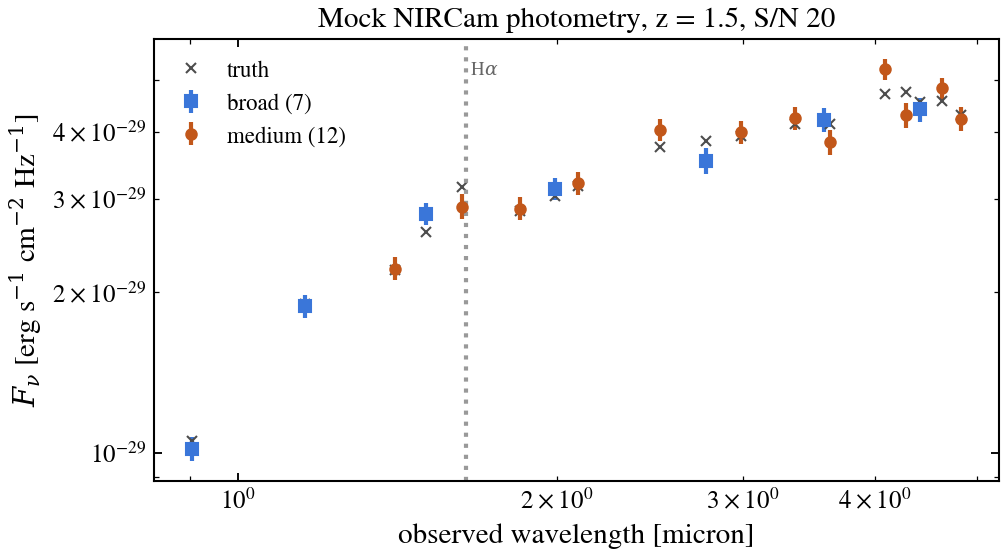

In [3]:
rng = np.random.default_rng(4)

truth = dict(FIXED_VALUES)
truth[MASS_KEY] = 10.3
truth["met_logzsol"] = -0.3
truth["dust_tau_diff"] = 0.3
for name in RATIO_KEYS:
    truth[name] = 0.0

flux_true = np.asarray(model.predict_photometry(truth))
noise = np.abs(flux_true) / SNR
flux_obs = flux_true + rng.normal(size=flux_true.shape) * noise

wave_um = effective_wavelengths_um(phot)
fig, ax = plt.subplots(figsize=(7, 4))
sel_b = np.arange(len(BROAD))
sel_m = np.arange(len(BROAD), len(BROAD) + len(MEDIUM))
ax.errorbar(
    wave_um[sel_b],
    flux_obs[sel_b],
    yerr=noise[sel_b],
    fmt="s",
    ms=6,
    color="#3a76d9",
    label="broad (7)",
)
ax.errorbar(
    wave_um[sel_m],
    flux_obs[sel_m],
    yerr=noise[sel_m],
    fmt="o",
    ms=5,
    color="#c2571a",
    label="medium (12)",
)
ax.plot(wave_um, flux_true, "x", ms=5, color="0.3", label="truth")
ax.axvline(6564.61e-4 * (1 + Z_GAL), ls=":", color="0.6")
ax.text(6564.61e-4 * (1 + Z_GAL), ax.get_ylim()[1] * 0.9, r" H$\alpha$", color="0.4", fontsize=9)
ax.set(
    xscale="log",
    yscale="log",
    xlabel="observed wavelength [micron]",
    ylabel=r"$F_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]",
    title=f"Mock NIRCam photometry, z = {Z_GAL}, S/N {SNR:.0f}",
)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "jwst_nonparametric_mock.png", dpi=110)
plt.show()

## Individual mode

MAP for the point estimate, then a posterior. With the bins fixed, the lever
that matters is trajectory length. Every row is six seeds, one fit per
process, 400 samples each, dense metric on the `mcmc_hmc` rows, blackjax
1.6.2. The effective-sample columns are exact: a given seed returns the same
chain every time. Wall moves with whatever else the machine is doing.

| sampler | warmup | wall | min ESS, median | min ESS, worst seed | divergences per run |
| --- | --- | --- | --- | --- | --- |
| `mcmc_nuts`, diagonal mass (default) | 400 | 85 s | 119 | 47 | 3.3 |
| `mcmc_nuts`, `dense_mass_matrix=True` | 400 | 49 s | 51 | 48 | 8.8 |
| `mcmc_hmc`, 20 leapfrog steps | 400 | 9 s | 10 | 3 | 1.3 |
| `mcmc_hmc`, 60 leapfrog steps | 1000 | 28 s | 30 | 23 | 1.7 |
| `mcmc_hmc`, 80 leapfrog steps | 1000 | 35 s | 111 | 31 | 2.5 |
| `mcmc_hmc`, 150 leapfrog steps | 1000 | 62 s | 118 | 64 | 1.7 |

The bin ratios are correlated, and a 20-step trajectory cannot cross that
geometry: it barely moves, returning 10 effective samples out of 400. Short
trajectories are also biased rather than merely noisy, and the bias falls
monotonically with length. Against the pooled 150-step posterior, the largest
parameter median shift is 0.31 sigma at 20 steps, 0.13 at 40, 0.09 at 60 and
0.05 at 80, in units of that posterior's own width.

The last two columns are why the fit below runs 150 steps. Cost per effective
sample favors 80 steps, at 0.32 seconds against 0.53 for 150 and 0.91 for
60, so a shorter trajectory is not automatically the cheaper one: 60 steps
loses on the median and on the cost at once. What separates 80 from 150 is
the floor. One seed in six returned 31 effective samples at 80 steps and 23
at 60, while no 150-step seed fell below 64. A short trajectory fails
occasionally rather than uniformly, and a page that is run once, with one
seed, has to be told the floor rather than the average.

Each row is a separate process, one fit each, because warmup can peak well
above the resident model. Six seeds because min ESS varies by a factor of
several between them and fewer can reorder the table: two samplers compared
from one fit each is not evidence. The numbers are specific to this model.
They were measured with `tau_bc` pinned at 0, and an earlier version of this
page that let it inherit its declared default of 1 returned 176 effective
samples at 60 steps on the seed that returns 30 here. A fixed nuisance value
is part of the geometry the sampler has to cross, not a detail beside it.

In [4]:
forward = ForwardModel.build(sed=model)

t0 = time.perf_counter()
map_post = forward.fit(flux_obs, noise, method="map", key=jax.random.PRNGKey(1), n_steps=300)
map_wall = time.perf_counter() - t0
map_logm = float(map_post.params[MASS_KEY])
print(f"MAP: {map_wall:.1f} s, log total mass = {map_logm:.2f} (truth {truth[MASS_KEY]:.2f})")

t0 = time.perf_counter()
posterior = forward.fit(
    flux_obs,
    noise,
    method="mcmc_hmc",
    key=jax.random.PRNGKey(2),
    n_warmup=N_WARMUP,
    n_samples=N_SAMPLES,
    n_leapfrog_steps=N_LEAPFROG,
    target_accept_rate=0.9,
    dense_mass_matrix=True,
    verbose=False,
)
nuts_wall = time.perf_counter() - t0


def min_ess(post):
    """Smallest effective sample size over the free parameters, and its name."""
    ess = {
        p: float(effective_sample_size(np.asarray(post.samples[p]).reshape(1, -1)))
        for p in model.spec.free_params
    }
    name = min(ess, key=ess.get)
    return ess[name], name


ess_val, ess_name = min_ess(posterior)
lo, med, hi = np.percentile(np.asarray(posterior.samples[MASS_KEY]), [16, 50, 84])
print(
    f"HMC ({N_LEAPFROG} leapfrog, dense mass): {nuts_wall:.1f} s, "
    f"min ESS {ess_val:.0f} ({ess_name}), {nuts_wall / ess_val:.2f} s/ESS"
)
print(
    f"log total mass = {med:.2f} [+{hi - med:.2f} -{med - lo:.2f}] (truth {truth[MASS_KEY]:.2f})"
)
print(f"divergences: {posterior.diagnostics.get('n_divergent', 0)}")

    step 200: loss=15.5301
  MAP (ADAM) complete in 0.7s, 300 steps, loss=14.3303
MAP: 6.1 s, log total mass = 10.33 (truth 10.30)


HMC (150 leapfrog, dense mass): 58.0 s, min ESS 203 (sfh_cont_log_total_mass), 0.29 s/ESS
log total mass = 10.29 [+0.05 -0.08] (truth 10.30)
divergences: 0


## Catalog mode

Eight galaxies at the same redshift, spread over a dex in mass, with their own
dust, metallicity and SFH shape: two rising, two declining, two constant, and
two with a burst in the youngest bin. `Catalog.fit` runs one vectorized
program over all of them, and `forward_chunk_size` is left at its `"auto"`
default, which sizes the batch from a memory budget; forcing `K = N` on a
model this heavy can exceed available RAM.

The sampler is the one from the table, which is convenient, because it is also
the only one that batches well. Vectorizing a trajectory whose length is
decided per step builds a far larger graph than a fixed-length one: batched
NUTS on this model spent over fifteen minutes in XLA compilation without
producing a sample, while fixed-length HMC compiles in seconds. The metric is
the difference from the individual fit, since batched warmup adapts a diagonal
one per galaxy. Read the per-galaxy effective sample sizes below before
trusting any single object: use the catalog pass to rank and flag, then refit
what matters with the dense-metric recipe above.

In [5]:
N_GAL = 8
SHAPES = {
    "rising": np.full(6, 0.4),
    "declining": np.full(6, -0.4),
    "constant": np.zeros(6),
    "burst": np.array([1.3, -0.3, 0.0, 0.0, 0.0, 0.0]),
}
SHAPE_ORDER = ["rising", "declining", "constant", "burst"] * 2

logm_true = rng.uniform(9.5, 10.8, N_GAL)
truths = []
band_names = list(phot.names)
table = {b: np.zeros(N_GAL) for b in band_names}
table.update({f"{b}_err": np.zeros(N_GAL) for b in band_names})
for i in range(N_GAL):
    tr = dict(truth)
    tr[MASS_KEY] = logm_true[i]
    tr["met_logzsol"] = rng.uniform(-0.8, 0.0)
    tr["dust_tau_diff"] = rng.uniform(0.1, 0.8)
    for k, r in zip(RATIO_KEYS, SHAPES[SHAPE_ORDER[i]] + rng.normal(0.0, 0.1, 6)):
        tr[k] = float(r)
    truths.append(tr)
    f_true = np.asarray(model.predict_photometry(tr))
    n = np.abs(f_true) / SNR
    f = f_true + rng.normal(size=f_true.shape) * n
    for j, b in enumerate(band_names):
        table[b][i] = f[j]
        table[f"{b}_err"][i] = n[j]

cat = Catalog(forward, table, flux_unit="cgs_fnu")

t0 = time.perf_counter()
catalog_post = cat.fit(
    key=jax.random.PRNGKey(6),
    method="mcmc_hmc",
    n_warmup=N_WARMUP,
    n_samples=N_SAMPLES,
    n_leapfrog_steps=N_LEAPFROG,
    target_accept_rate=0.9,
    verbose=False,
)
cat_wall = time.perf_counter() - t0

logm_med, logm_lo, logm_hi, ess_per_gal = [], [], [], []
for p in catalog_post:
    s = np.asarray(p.samples[MASS_KEY])
    q16, q50, q84 = np.percentile(s, [16, 50, 84])
    logm_med.append(q50)
    logm_lo.append(q16)
    logm_hi.append(q84)
    ess_per_gal.append(min_ess(p)[0])
logm_med, logm_lo, logm_hi = map(np.array, (logm_med, logm_lo, logm_hi))
resid = logm_med - logm_true
print(
    f"catalog HMC: {cat_wall:.1f} s = {cat_wall / N_GAL:.1f} s per galaxy "
    f"({N_GAL} galaxies, one program)"
)
print(f"log total mass recovery: bias {resid.mean():+.2f} dex, scatter {resid.std():.2f} dex")
print(f"min ESS per galaxy: {', '.join(f'{e:.0f}' for e in ess_per_gal)}")
print(f"divergences: {catalog_post.diagnostics.get('n_divergent_total', 'n/a')}")

catalog HMC: 250.3 s = 31.3 s per galaxy (8 galaxies, one program)
log total mass recovery: bias +0.03 dex, scatter 0.15 dex
min ESS per galaxy: 12, 145, 113, 9, 12, 397, 56, 21
divergences: 6


## What the catalog fits look like

Three of the eight, one per SFH shape: the photometry with the posterior model
over it, the recovered history against the input, and the mass posterior. The
histories are drawn from the posterior, so the width of the band is the
constraint the bands actually place on each age bin, and they stop at the age
of the universe because that is where the kernel stops counting.

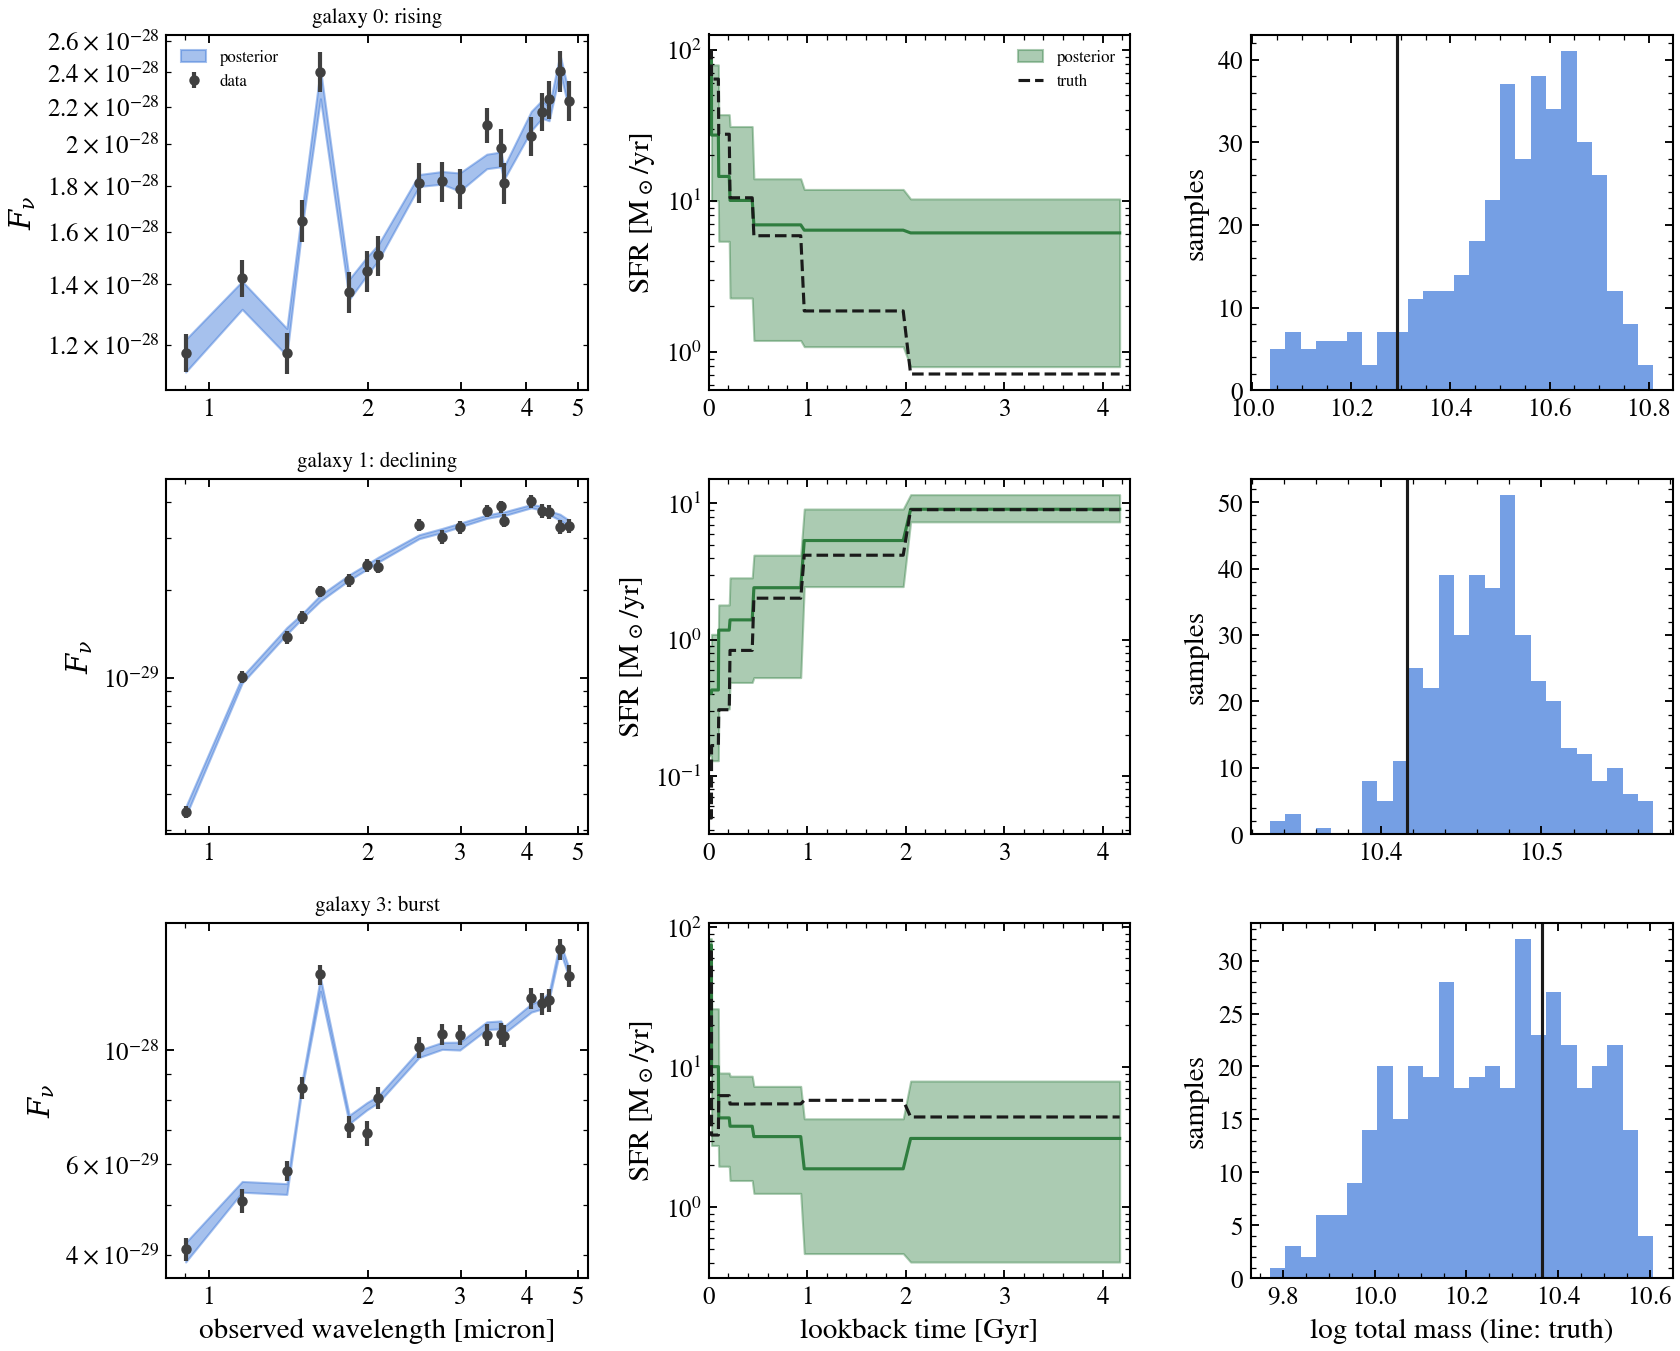

In [6]:
N_DRAWS = 40
SHOW = [0, 1, 3]  # rising, declining, burst
ORDER = np.argsort(wave_um)  # band lists are broad-then-medium, not by wavelength


def draw_products(post, key):
    """Model photometry and SFH for N_DRAWS posterior draws."""
    draws = post.resample(key, n=N_DRAWS)
    fluxes, sfrs, lbt = [], [], None
    for i in range(N_DRAWS):
        p = {**FIXED_VALUES, **{k: float(v[i]) for k, v in draws.items()}}
        fluxes.append(np.asarray(model.predict_photometry(p)))
        s = model.predict_state(p)
        sfrs.append(np.asarray(s.derived["sfr_history"]))
        if lbt is None:
            lbt = np.asarray(s.derived["sfh_grid_lbt_yr"]) / 1e9
    return np.array(fluxes), np.array(sfrs), lbt


fig, axes = plt.subplots(len(SHOW), 3, figsize=(11.5, 3.1 * len(SHOW)))
for row, gal in enumerate(SHOW):
    post = catalog_post[gal]
    fluxes, sfrs, lbt = draw_products(post, jax.random.PRNGKey(20 + gal))
    truth_state = model.predict_state(truths[gal])
    sfr_truth = np.asarray(truth_state.derived["sfr_history"])
    obs = np.array([table[b][gal] for b in band_names])
    err = np.array([table[f"{b}_err"][gal] for b in band_names])

    ax = axes[row, 0]
    ax.errorbar(
        wave_um[ORDER],
        obs[ORDER],
        yerr=err[ORDER],
        fmt="o",
        ms=4,
        color="0.25",
        label="data",
        zorder=3,
    )
    ax.fill_between(
        wave_um[ORDER],
        np.percentile(fluxes, 16, axis=0)[ORDER],
        np.percentile(fluxes, 84, axis=0)[ORDER],
        color="#3a76d9",
        alpha=0.45,
        label="posterior",
    )
    ax.set(xscale="log", yscale="log", ylabel=r"$F_\nu$")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(["1", "2", "3", "4", "5"])
    ax.set_title(f"galaxy {gal}: {SHAPE_ORDER[gal]}", fontsize=10)
    if row == 0:
        ax.legend(frameon=False, fontsize=8)

    ax = axes[row, 1]
    vis = lbt <= T_UNIV  # older than the universe at z: masked by the CSP kernel
    ax.fill_between(
        lbt[vis],
        np.percentile(sfrs, 16, axis=0)[vis],
        np.percentile(sfrs, 84, axis=0)[vis],
        color="#2f7d3f",
        alpha=0.4,
        label="posterior",
    )
    ax.plot(lbt[vis], np.median(sfrs, axis=0)[vis], color="#2f7d3f", lw=1.5)
    ax.plot(lbt[vis], sfr_truth[vis], color="0.1", lw=1.5, ls="--", label="truth")
    ax.set(xlim=(0, T_UNIV), yscale="log", ylabel=r"SFR [M$_\odot$/yr]")
    if row == 0:
        ax.legend(frameon=False, fontsize=8)

    ax = axes[row, 2]
    ax.hist(np.asarray(post.samples[MASS_KEY]).ravel(), bins=25, color="#3a76d9", alpha=0.7)
    ax.axvline(logm_true[gal], color="0.1", lw=1.5)
    ax.set(ylabel="samples")

axes[-1, 0].set_xlabel("observed wavelength [micron]")
axes[-1, 1].set_xlabel("lookback time [Gyr]")
axes[-1, 2].set_xlabel("log total mass (line: truth)")
fig.tight_layout()
fig.savefig(FIG_DIR / "jwst_nonparametric_examples.png", dpi=110)
plt.show()

## Recovery

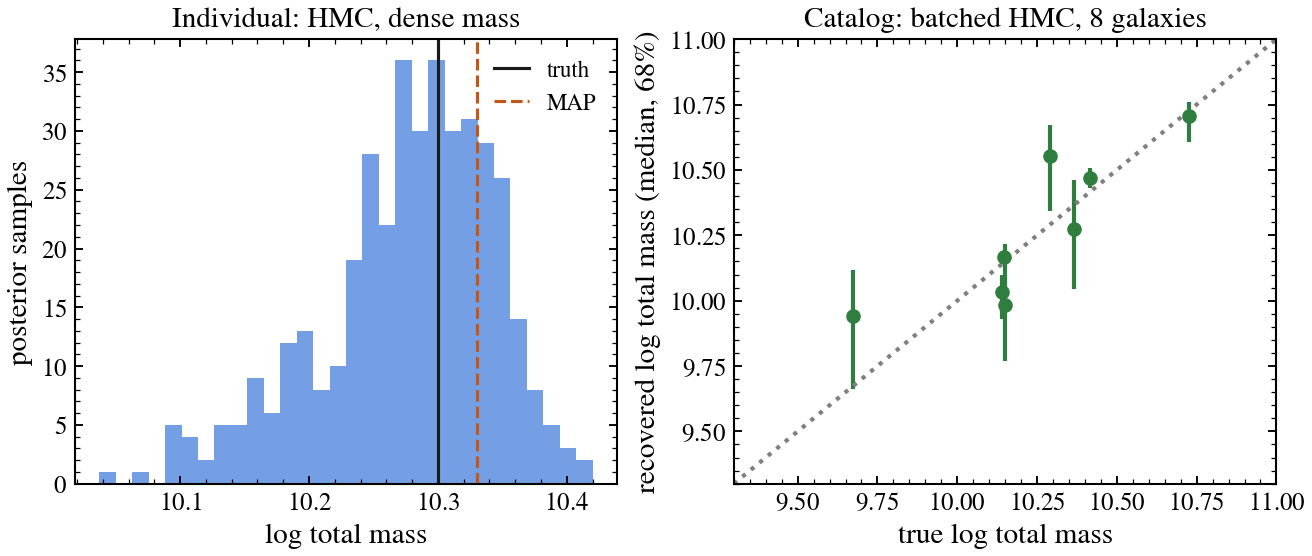

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

ax1.hist(np.asarray(posterior.samples[MASS_KEY]).ravel(), bins=30, color="#3a76d9", alpha=0.7)
ax1.axvline(truth[MASS_KEY], color="0.1", lw=1.5, label="truth")
ax1.axvline(map_logm, color="#c2571a", ls="--", lw=1.5, label="MAP")
ax1.set(xlabel="log total mass", ylabel="posterior samples", title="Individual: HMC, dense mass")
ax1.legend(frameon=False)

ax2.errorbar(
    logm_true,
    logm_med,
    yerr=[logm_med - logm_lo, logm_hi - logm_med],
    fmt="o",
    ms=6,
    color="#2f7d3f",
)
lims = [9.3, 11.0]
ax2.plot(lims, lims, ls=":", color="0.5")
ax2.set(
    xlim=lims,
    ylim=lims,
    xlabel="true log total mass",
    ylabel="recovered log total mass (median, 68%)",
    title=f"Catalog: batched HMC, {N_GAL} galaxies",
)

fig.tight_layout()
fig.savefig(FIG_DIR / "jwst_nonparametric_recovery.png", dpi=110)
plt.show()

## Cost summary

In [8]:
print(f"{'stage':<44}{'wall':>10}")
print("-" * 54)
print(f"{'model build + WavePrecomp (one-time)':<44}{build_wall:>8.1f} s")
print(f"{'MAP, 9 parameters':<44}{map_wall:>8.1f} s")
print(f"{'HMC posterior, single galaxy':<44}{nuts_wall:>8.1f} s")
print(f"{'catalog HMC, per galaxy':<44}{cat_wall / N_GAL:>8.1f} s")

stage                                             wall
------------------------------------------------------
model build + WavePrecomp (one-time)             1.5 s
MAP, 9 parameters                                6.1 s
HMC posterior, single galaxy                    58.0 s
catalog HMC, per galaxy                         31.3 s


Rules of thumb from this configuration, on a laptop CPU with a warm compile
cache. A MAP takes a few seconds, and a single-galaxy posterior that mixes
takes about a minute. Catalog mode costs tens of seconds per galaxy and takes
fewer effective samples each, which is the trade it exists to make.

A fit far outside those ranges usually means a wrong setting. Check three
things, in order: that the bin edges reach the age of the universe at the fit
redshift and no further, that the model was built with `WavePrecomp`, and that
the trajectory is long enough. Then check what the sampler did rather than how
long it took: a nonparametric fit that returns in seconds has almost certainly
not moved, and one that returns a low divergence count alongside a min ESS in
the single digits has not either. The "Choosing an inference method" page has
the sampler decision table.